In [1]:
# 1. Setup + fetch data
import sys, warnings
from pathlib import Path

_nb = globals().get("__vsc_ipynb_file__")
ROOT = None
for start in ([Path(_nb)] if _nb else []) + [Path.cwd()]:
    p = start.resolve()
    if p.suffix == ".ipynb": p = p.parent
    for candidate in (p, *p.parents):
        if (candidate / "vol_surface.py").is_file():
            ROOT = candidate; break
    if ROOT: break
if not ROOT: raise FileNotFoundError("Open Signal_Monitor in Cursor.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
import plotly.graph_objects as go
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update(mpl.rcParamsDefault)

from vol_surface import VolSurfaceConfig, VolSurfaceStudy, latest_business_session
from data_fetcher import RateLimiter, SafeFetchSession

# Define the target underlying index ticker: "US..SPX", "US..IXIC" (Nasdaq), or "US..DJI" (Dow Jones)
UNDERLYING_TICKER = "US..SPX"

cfg = VolSurfaceConfig(underlying=UNDERLYING_TICKER, max_dte=60, lookback_days=15)

import futu as ft
limiter = RateLimiter(600)
session = SafeFetchSession(limiter, cfg)
ctx = ft.OpenQuoteContext(host=cfg.host, port=cfg.port)
try:
    df = session.fetch_and_cache(ctx, max_retries=3)
finally:
    ctx.close()
print(f"Live: {len(df)} contracts")

study = VolSurfaceStudy(cfg)
study.load_history()
dates = sorted(study.surfaces.keys())
print(f"Loaded {len(dates)} real sessions for {UNDERLYING_TICKER}")
print(dates[0].strftime("%Y-%m-%d"), "->", dates[-1].strftime("%Y-%m-%d"))

2026-07-05 17:07:39,301 | 3628 | 27724 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7479460980011486142(1) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x0000016CCBEBBC20>
Live: 7430 contracts
2026-07-05 17:08:17,867 | 3628 | 7504 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(1) reason=CallClose
Loaded 11 sessions for US..SPX
2026-06-19 -> 2026-07-03


2026-07-05 17:08:58,776 | 3628 | 7504 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(2) reason=CallClose


In [2]:
# 2. Run analysis

result = study.analyze()
today_f = result["today"]
print(f"As of {result['dates'][-1]}  ATM 30d IV={today_f.get('atm_iv_30d')}  skew 25d={today_f.get('skew_25d')}")

2026-07-05 17:08:55,643 | 3628 | 27724 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7479461300213717484(2) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x0000016CCD512690>
PCA: PC1=98.2% PC2=1.8% PC3=0.0%
Today: z_PC1=+14.14 z_PC2=-0.80


In [3]:
# 3. Bloomberg-style 3D vol surface with IV/local vol toggle (using Moneyness K/S)

# Call the encapsulated 3D Moneyness graph visualization method
fig = study.plot_bloomberg_3d_surface()
fig.show()

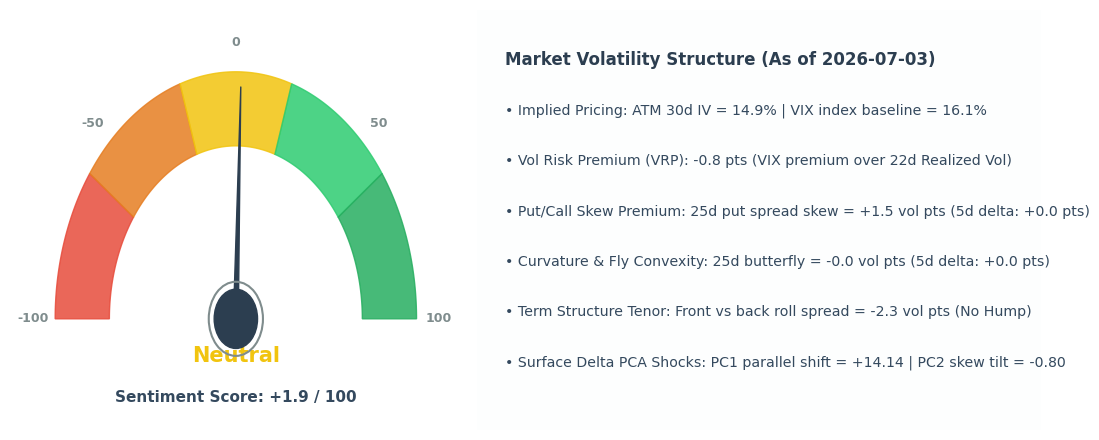

In [4]:
# 4. Sentiment compass / PCA gauge removed.
# Dealer GEX (TTM buckets + strike profile) is on the live dashboard: python app.py